In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [25]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

In [ ]:
from model.clip   import processor as clip_processor
from model.dinov2 import processor as dinov2_processor
from model.siglip import processor as siglip_processor

In [ ]:
print(clip_processor.image_processor)

In [ ]:
print(siglip_processor)

In [ ]:
print(dinov2_processor)

In [35]:
train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [ ]:
print(len(train_dataloader))
images, lables = next(iter(train_dataloader))
# images and lables blongs to 32 samples (1 batch) 

86744


In [65]:
# print(images,lables)
Y = {
            k: v for k, v in lables.items()
        }
# print(lables.items())
for key in lables:
    print(key)

gender
age
race


In [42]:
print(images,lables)

tensor([[[[ 0.2953,  0.2953,  0.2953,  ...,  0.2953,  0.2953,  0.2953],
          [ 0.2953,  0.2953,  0.2953,  ...,  0.2953,  0.2953,  0.2953],
          [ 0.2953,  0.2953,  0.2953,  ...,  0.2953,  0.2953,  0.2953],
          ...,
          [ 0.2953,  0.2953,  0.2953,  ...,  0.2953,  0.2953,  0.2953],
          [ 0.2953,  0.2953,  0.2953,  ...,  0.2953,  0.2953,  0.2953],
          [ 0.2953,  0.2953,  0.2953,  ...,  0.2953,  0.2953,  0.2953]],

         [[ 0.3940,  0.3940,  0.3940,  ...,  0.3940,  0.3940,  0.3940],
          [ 0.3940,  0.3940,  0.3940,  ...,  0.3940,  0.3940,  0.3940],
          [ 0.3940,  0.3940,  0.3940,  ...,  0.3940,  0.3940,  0.3940],
          ...,
          [ 0.3940,  0.3940,  0.3940,  ...,  0.3940,  0.3940,  0.3940],
          [ 0.3940,  0.3940,  0.3940,  ...,  0.3940,  0.3940,  0.3940],
          [ 0.3940,  0.3940,  0.3940,  ...,  0.3940,  0.3940,  0.3940]],

         [[ 0.5532,  0.5532,  0.5532,  ...,  0.5532,  0.5532,  0.5532],
          [ 0.5532,  0.5532,  

In [4]:
df = pd.DataFrame({
    "age": train_set.dataset["age"],
    "gender": train_set.dataset["gender"],
    "race": train_set.dataset["race"],
})
print(train_set.dataset)

Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 86744
})


In [5]:
age_names = ["0: 0-2","1: 3-9","2: 10-19","3: 20-29",
             "4: 30-39","5: 40-49","6: 50-59",
             "7: 60-69","8: more than 70"]
gender_names = ["0: Male","1: Female"]
race_names = ["0: East Asian","1: Indian","2: Black",
              "3: White","4: Middle Eastern",
              "5: Latino_Hispanic","6: Southeast Asian"]

## Gender

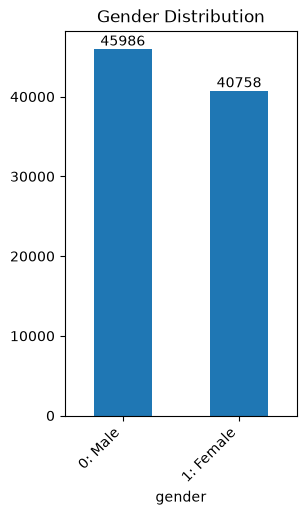

In [6]:

counts = df['gender'].value_counts().sort_index()
# print(counts)

ax = counts.plot(kind='bar', figsize=(3,5), title='Gender Distribution')
ax.set_xticklabels(gender_names, rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.show()

## Age

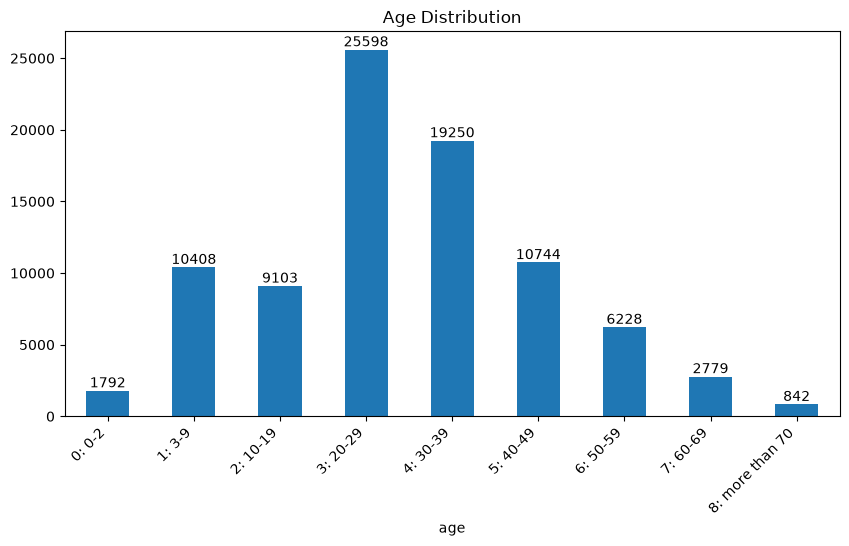

In [7]:

counts = df['age'].value_counts().sort_index()


ax = counts.plot(kind='bar', figsize=(10,5), title='Age Distribution')
ax.set_xticklabels(age_names, rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.show()

## Race

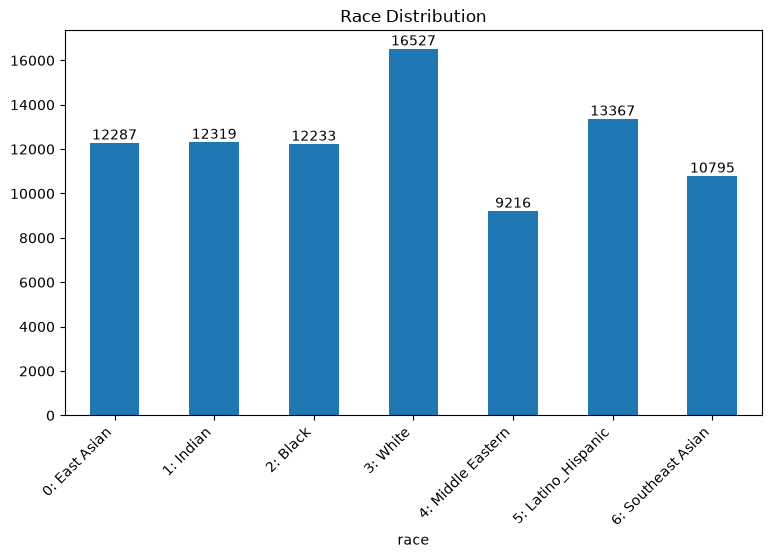

In [8]:
counts = df['race'].value_counts().sort_index()

ax = counts.plot(kind='bar', figsize=(9,5), title='Race Distribution')
ax.set_xticklabels(race_names, rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.show()

## Describe

In [9]:
print(df['gender'].value_counts())
print(df['age'].value_counts())
print(df['race'].value_counts())

print(df.describe(include="all"))
print("\nImbalance ratios:")
for col in ["age", "gender", "race"]:
    counts = df[col].value_counts()
    print(f"{col}: max/min ratio = {counts.max()/counts.min():.2f}")



gender
0    45986
1    40758
Name: count, dtype: int64
age
3    25598
4    19250
5    10744
1    10408
2     9103
6     6228
7     2779
0     1792
8      842
Name: count, dtype: int64
race
3    16527
5    13367
1    12319
0    12287
2    12233
6    10795
4     9216
Name: count, dtype: int64
                age        gender          race
count  86744.000000  86744.000000  86744.000000
mean       3.454821      0.469865      2.937782
std        1.637914      0.499094      1.955181
min        0.000000      0.000000      0.000000
25%        3.000000      0.000000      1.000000
50%        3.000000      0.000000      3.000000
75%        4.000000      1.000000      5.000000
max        8.000000      1.000000      6.000000

Imbalance ratios:
age: max/min ratio = 30.40
gender: max/min ratio = 1.13
race: max/min ratio = 1.79


## Plot Random Samples

In [13]:
import math

def show_samples(dataframe, n=8, cols=4):
    samples = dataframe.sample(n)
    
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 3, rows * 3))
    
    for i, (sample_idx, s) in enumerate(samples.iterrows()):
        img = train_set[sample_idx][0]
        plt.subplot(rows, cols, i+1)  # rows, cols
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{sample_idx},{race_names[s['race']]}")
    
    plt.show()

In [11]:
age_class_0 = df[df['age'] == 0]
age_class_7 = df[df['age'] == 7]
age_class_8 = df[df['age'] == 8]

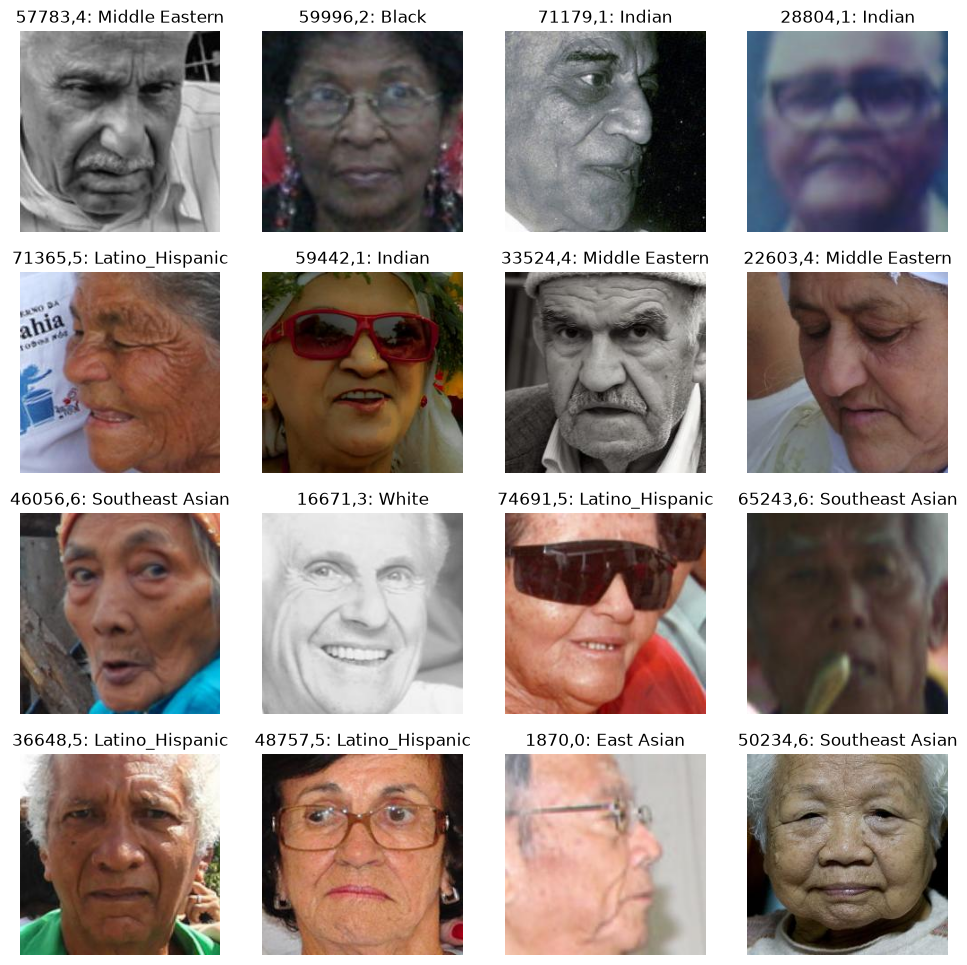

In [12]:
show_samples(age_class_8, n=16)